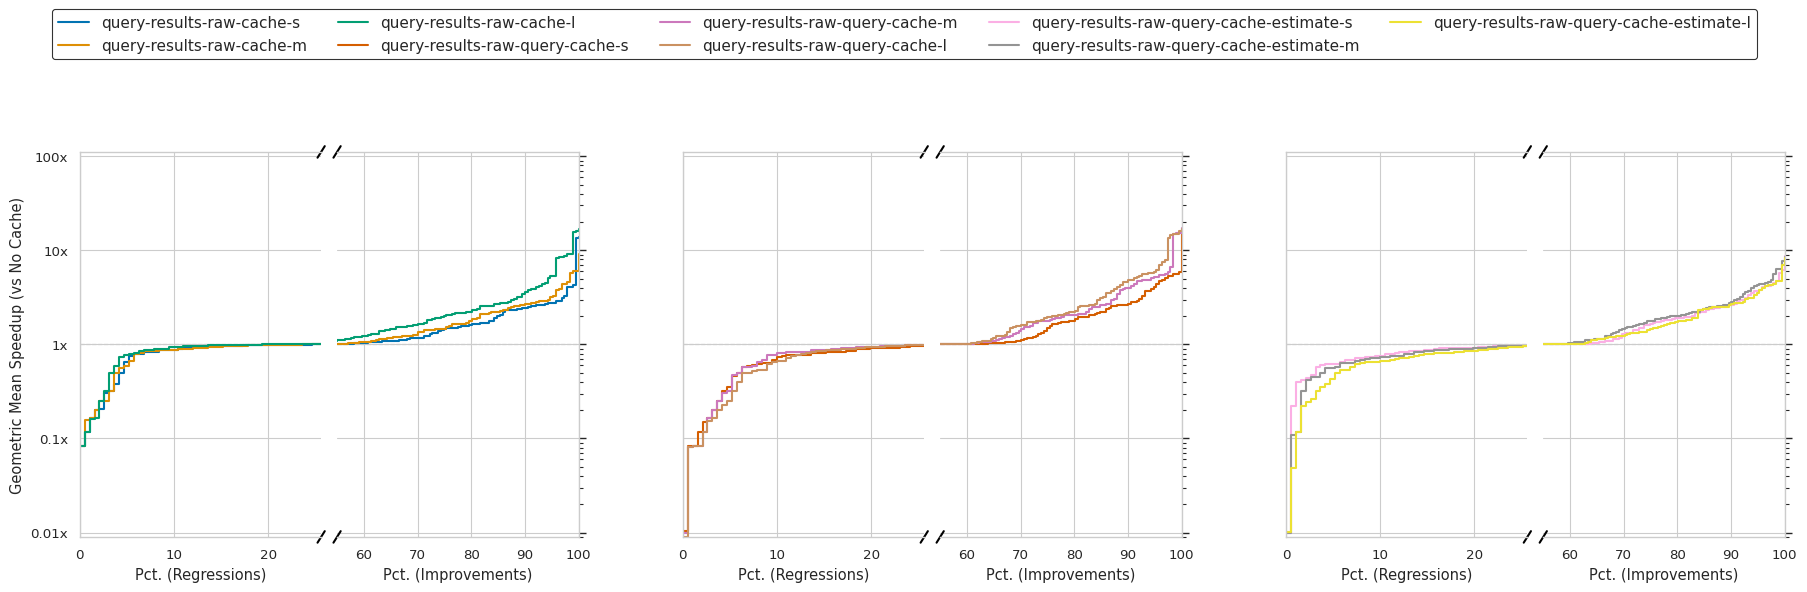

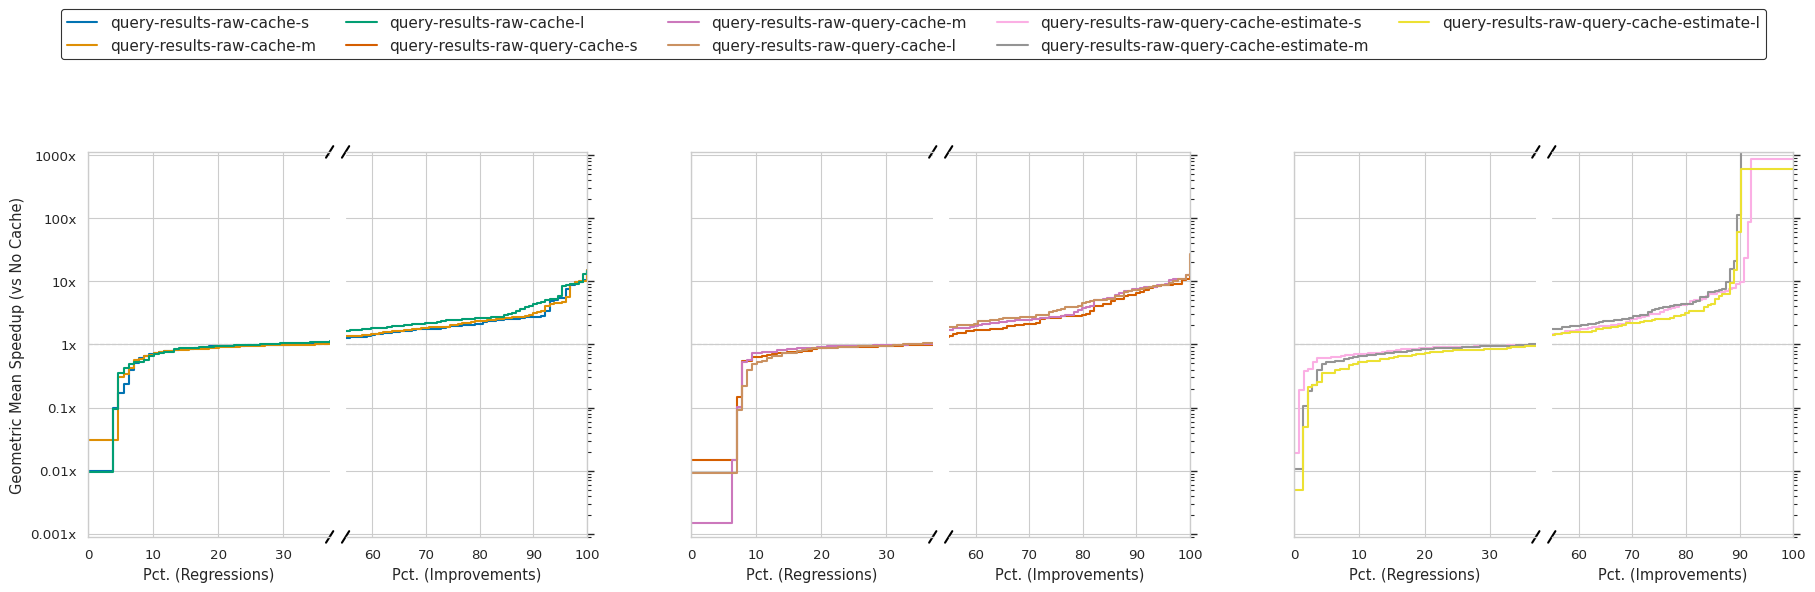

In [8]:
from data_analysis import get_algorithm_labels
import json
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_speedup_from_locations(baseline_locations, cache_locations, metric='time', log_scale=True, algorithm_labels=None, save_location=None):
    """
    Plots a logarithmic inverted ECDF comparing multiple caching strategies.
    Supports latency and throughput-normalized speedups.
    Valid 'metric' options: 'time', 'first_ts', 'last_ts', 'throughput'

    Parameters:
    - baseline_locations: List of file paths to baseline data.
    - cache_locations: List of file paths to cache evaluation data.
    - metric: The evaluation metric to calculate speedup against.
    - log_scale: Boolean to apply logarithmic scaling to the Y-axis.
    - algorithm_labels: Optional list of strings matching the length of cache_locations for legend labeling.
    - save_location: Optional file path string to save the resulting PDF/PNG.
    """

    def parse_file(filepath):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                timestamps = item.get('timestamps', [])

                first_ts = timestamps[0] if timestamps else None
                last_ts = timestamps[-1] if timestamps else None
                num_results = len(timestamps)

                throughput = 0.0
                if num_results > 0 and last_ts and last_ts > 0:
                    throughput = num_results / last_ts

                records.append({
                    'name': item.get('name'),
                    'id': item.get('id'),
                    'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                    'time': item.get('time'),
                    'first_ts': first_ts,
                    'last_ts': last_ts,
                    'num_results': num_results,
                    'throughput': throughput
                })
        return pd.DataFrame(records)

    # 1. Process Baseline Data
    df_base_list = [parse_file(loc) for loc in baseline_locations]
    df_base = pd.concat(df_base_list, ignore_index=True)

    df_base_agg = df_base.groupby(['name', 'id', 'template']).agg({
        'time': 'median',
        'first_ts': 'median',
        'last_ts': 'median',
        'num_results': 'median',
        'throughput': 'median'
    }).reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))

    # 2. Process Each Cache Strategy
    for i, cache_loc in enumerate(cache_locations):
        # Resolve strategy label
        if algorithm_labels and i < len(algorithm_labels):
            strategy_label = algorithm_labels[i]
        else:
            strategy_label = os.path.basename(cache_loc).replace('.json', '')

        df_cache = parse_file(cache_loc)
        df_cache_agg = df_cache.groupby(['name', 'id', 'template']).agg({
            'time': 'median',
            'first_ts': 'median',
            'last_ts': 'median',
            'num_results': 'median',
            'throughput': 'median'
        }).reset_index()

        merged = pd.merge(df_base_agg, df_cache_agg, on=['name', 'id', 'template'], suffixes=('_base', '_cache'))

        safe_base_results = np.maximum(1, merged['num_results_base'])
        safe_cache_results = np.maximum(1, merged['num_results_cache'])

        # 3. Calculate Speedup
        if metric == 'first_ts':
            valid_mask = (merged['num_results_base'] > 0) & (merged['num_results_cache'] > 0)
            merged = merged[valid_mask].copy()
            merged['speedup'] = merged['first_ts_base'] / merged['first_ts_cache']

        elif metric == 'throughput':
            tb = merged['throughput_base']
            tc = merged['throughput_cache']

            # Keep queries where at least one succeeded
            valid_mask = (tb > 0) | (tc > 0)
            merged = merged[valid_mask].copy()

            tb = merged['throughput_base']
            tc = merged['throughput_cache']

            # Identify the three categories
            both_succeeded = (tb > 0) & (tc > 0)
            rescued_by_cache = (tb == 0) & (tc > 0)
            broken_by_cache = (tb > 0) & (tc == 0)

            # Calculate normal speedups to find natural bounds
            normal_speedups = tc[both_succeeded] / tb[both_succeeded]

            max_normal = normal_speedups.max() if not normal_speedups.empty else 10.0
            min_normal = normal_speedups.min() if not normal_speedups.empty else 0.1

            # Create distinct ledges (1 order of magnitude beyond max/min)
            infinity_proxy = max_normal * 10.0
            zero_proxy = min_normal / 10.0

            # Assign speedups categorically
            speedup_col = pd.Series(index=merged.index, dtype=float)
            speedup_col[both_succeeded] = normal_speedups
            speedup_col[rescued_by_cache] = infinity_proxy
            speedup_col[broken_by_cache] = zero_proxy

            merged['speedup'] = speedup_col

        elif metric in ['time', 'last_ts']:
            latency_ratio = merged[f'{metric}_base'] / merged[f'{metric}_cache']
            result_ratio = safe_cache_results / safe_base_results
            merged['speedup'] = latency_ratio * result_ratio

        else:
            raise ValueError("Invalid metric. Choose 'time', 'first_ts', 'last_ts', or 'throughput'.")

        speedups = merged['speedup'].dropna().values
        speedups = speedups[speedups > 0]
        speedups.sort()

        if len(speedups) > 0:
            percentiles = np.linspace(0, 100, len(speedups))
            ax.step(percentiles, speedups, where='post', linewidth=2, label=strategy_label)

    # 4. Apply Graph Formatting
    ax.axhline(1.0, color='gray', linestyle='-', linewidth=1.5, zorder=1)

    if log_scale:
        ax.set_yscale('log')
        ymin, ymax = ax.get_ylim()

        if ymin > 0 and ymax > 0:
            max_log_dev = max(abs(np.log10(ymin)), abs(np.log10(ymax)))
            ax.set_ylim(10 ** (-max_log_dev), 10 ** max_log_dev)

    metric_labels = {
        'time': 'Total Execution Time',
        'first_ts': 'First Result Arrival Time',
        'last_ts': 'Last Result Arrival Time',
        'throughput': 'Throughput'
    }
    display_metric = metric_labels.get(metric, metric)

    ax.set_xlabel('Query Percentile')
    ax.set_ylabel('Speedup Factor (Baseline / Cached)')
    ax.set_title(f'Caching Speedup Quantile Plot: {display_metric}')

    ax.grid(True, which="both", linestyle="--", alpha=0.3)
    ax.legend(title="Caching Strategy")

    plt.tight_layout()

    # 5. Save and Display
    if save_location:
        output_dir = os.path.dirname(save_location)
        if output_dir:
            os.makedirs(output_dir, exist_ok=True)
        plt.savefig(save_location, bbox_inches='tight')
        print(f"Plot successfully saved to: {save_location}")

    plt.show()


import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

def plot_faceted_speedup(
    baseline_locations,
    cache_locations_1,
    cache_locations_2,
    cache_locations_3,
    metric='time',
    log_scale=True,
    algorithm_labels_1=None,
    algorithm_labels_2=None,
    algorithm_labels_3=None,
    layout='vertical',
    save_location=None
):
    """
    Plots a faceted, logarithmic inverted ECDF with a split x-axis comparing caching strategies.
    Applies strict academic styling via Seaborn.
    """

    # Apply Target Styling
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    colors = sns.color_palette("colorblind", n_colors=10) # Accommodates up to 10 unique algorithms

    def parse_file(filepath):
        records = []
        with open(filepath, 'r') as f:
            data = json.load(f)
            if not isinstance(data, list):
                data = [data]

            for item in data:
                timestamps = item.get('timestamps', [])
                first_ts = timestamps[0] if timestamps else None
                last_ts = timestamps[-1] if timestamps else None
                num_results = len(timestamps)

                throughput = 0.0
                if num_results > 0 and last_ts and last_ts > 0:
                    throughput = num_results / last_ts

                records.append({
                    'name': item.get('name'),
                    'id': item.get('id'),
                    'template': item.get('sequenceElement', {}).get('template', 'unknown'),
                    'time': item.get('time'),
                    'first_ts': first_ts,
                    'last_ts': last_ts,
                    'num_results': num_results,
                    'throughput': throughput
                })
        return pd.DataFrame(records)

    # 1. Process Baseline Data
    df_base = pd.concat([parse_file(loc) for loc in baseline_locations], ignore_index=True)
    df_base_agg = df_base.groupby(['name', 'id', 'template']).agg({
        'time': 'median', 'first_ts': 'median', 'last_ts': 'median',
        'num_results': 'median', 'throughput': 'median'
    }).reset_index()

    # 2. Define Speedup Calculation
    def extract_curves(cache_locations, labels):
        curves = []
        for i, cache_loc in enumerate(cache_locations):
            label = labels[i] if labels and i < len(labels) else os.path.basename(cache_loc).replace('.json', '')
            df_cache = parse_file(cache_loc)
            df_cache_agg = df_cache.groupby(['name', 'id', 'template']).agg({
                'time': 'median', 'first_ts': 'median', 'last_ts': 'median',
                'num_results': 'median', 'throughput': 'median'
            }).reset_index()

            merged = pd.merge(df_base_agg, df_cache_agg, on=['name', 'id', 'template'], suffixes=('_base', '_cache'))
            safe_base_results = np.maximum(1, merged['num_results_base'])
            safe_cache_results = np.maximum(1, merged['num_results_cache'])

            if metric == 'first_ts':
                merged = merged[(merged['num_results_base'] > 0) & (merged['num_results_cache'] > 0)].copy()
                merged['speedup'] = merged['first_ts_base'] / merged['first_ts_cache']

            elif metric == 'throughput':
                tb, tc = merged['throughput_base'], merged['throughput_cache']
                merged = merged[(tb > 0) | (tc > 0)].copy()
                tb, tc = merged['throughput_base'], merged['throughput_cache']

                both_succeeded = (tb > 0) & (tc > 0)
                normal_speedups = tc[both_succeeded] / tb[both_succeeded]

                max_norm = normal_speedups.max() if not normal_speedups.empty else 10.0
                min_norm = normal_speedups.min() if not normal_speedups.empty else 0.1

                speedup_col = pd.Series(index=merged.index, dtype=float)
                speedup_col[both_succeeded] = normal_speedups
                speedup_col[(tb == 0) & (tc > 0)] = max_norm * 10.0
                speedup_col[(tb > 0) & (tc == 0)] = min_norm / 10.0
                merged['speedup'] = speedup_col

            elif metric in ['time', 'last_ts']:
                latency_ratio = merged[f'{metric}_base'] / merged[f'{metric}_cache']
                merged['speedup'] = latency_ratio * (safe_cache_results / safe_base_results)
            else:
                raise ValueError("Invalid metric.")

            speedups = merged['speedup'].dropna().values
            speedups = speedups[speedups > 0]
            speedups.sort()

            if len(speedups) > 0:
                percentiles = np.linspace(0, 100, len(speedups))
                curves.append((label, percentiles, speedups))
        return curves

    # 3. Process Data Groups
    data_groups = [
        extract_curves(cache_locations_1, algorithm_labels_1),
        extract_curves(cache_locations_2, algorithm_labels_2),
        extract_curves(cache_locations_3, algorithm_labels_3)
    ]

    # 4. Determine Dynamic X-Axis Split Bounds (5% Threshold) & Global Y Limits
    p1, p2 = 0.0, 100.0
    global_min, global_max = 1.0, 1.0

    for group in data_groups:
        for _, p, s in group:
            if len(s) == 0: continue
            global_min = min(global_min, s.min())
            global_max = max(global_max, s.max())

            regs, imps = p[s <= 0.95], p[s >= 1.05]
            if len(regs) > 0: p1 = max(p1, regs.max())
            if len(imps) > 0: p2 = min(p2, imps.min())

    p1 = min(p1 + 1, 45)
    p2 = max(p2 - 1, 55)

    if log_scale and global_min > 0 and global_max > 0:
        max_log_dev = max(abs(np.log10(global_min)), abs(np.log10(global_max)))
        y_lims = (10 ** (-max_log_dev), 10 ** max_log_dev)
    else:
        y_lims = (global_min, global_max)

    # 5. Initialize Grid Based on Layout Parameter
    if layout == 'vertical':
        fig = plt.figure(figsize=(10, 12))
        gs = fig.add_gridspec(3, 2, width_ratios=[1, 1], wspace=0.08, hspace=0.35)
        ax_pairs = [
            (fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])),
            (fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])),
            (fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1]))
        ]
    elif layout == 'horizontal':
        fig = plt.figure(figsize=(22, 5))
        gs = fig.add_gridspec(1, 8, width_ratios=[1, 1, 0.3, 1, 1, 0.3, 1, 1], wspace=0.08)
        ax_pairs = [
            (fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])),
            (fig.add_subplot(gs[0, 3]), fig.add_subplot(gs[0, 4])),
            (fig.add_subplot(gs[0, 6]), fig.add_subplot(gs[0, 7]))
        ]
    else:
        raise ValueError("Invalid layout. Choose 'vertical' or 'horizontal'.")

    # 6. Plot Data and Format Split Axes
    global_color_idx = 0
    legend_handles = {}

    for row_idx, (group, (ax_left, ax_right)) in enumerate(zip(data_groups, ax_pairs)):
        for label, percentiles, speedups in group:

            # Map algorithm to a consistent color
            if label not in legend_handles:
                current_color = colors[global_color_idx % len(colors)]
                global_color_idx += 1
            else:
                current_color = legend_handles[label].get_color()

            line, = ax_left.step(percentiles, speedups, where='post', linewidth=1.5, color=current_color, label=label)
            ax_right.step(percentiles, speedups, where='post', linewidth=1.5, color=current_color, label=label)

            if label not in legend_handles:
                legend_handles[label] = line

        # Apply Axis Limits and Grid Formatting
        ax_left.set_xlim(0, p1)
        ax_right.set_xlim(p2, 100)

        for ax in (ax_left, ax_right):
            ax.set_ylim(y_lims)
            # Use styling provided in prompt for baseline
            ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)

            if log_scale:
                ax.set_yscale('log')
                ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}x'))

        # Clean Axis Break Styling
        ax_left.spines['right'].set_visible(False)
        ax_right.spines['left'].set_visible(False)

        ax_right.yaxis.tick_right()
        ax_right.tick_params(labelright=False)
        ax_right.tick_params(left=False)

        # Draw diagonal cut marks
        d = 0.015
        kwargs = dict(transform=ax_left.transAxes, color='black', clip_on=False, linewidth=1.5)
        ax_left.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        ax_left.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

        kwargs.update(transform=ax_right.transAxes)
        ax_right.plot((-d, +d), (-d, +d), **kwargs)
        ax_right.plot((-d, +d), (1 - d, 1 + d), **kwargs)

        # Label Management
        if layout == 'vertical':
            if row_idx == 2:
                ax_left.set_xlabel('Pct. (Regressions)')
                ax_right.set_xlabel('Pct. (Improvements)')
            if row_idx == 1:
                ax_left.set_ylabel('Geometric Mean Speedup (vs No Cache)')
        elif layout == 'horizontal':
            ax_left.set_xlabel('Pct. (Regressions)')
            ax_right.set_xlabel('Pct. (Improvements)')
            if row_idx == 0:
                ax_left.set_ylabel('Geometric Mean Speedup (vs No Cache)')
            else:
                ax_left.tick_params(labelleft=False)

    # 7. Global Legend Construction
    fig.legend(
        handles=list(legend_handles.values()),
        labels=list(legend_handles.keys()),
        loc='lower center',
        bbox_to_anchor=(0.5, 1.05 if layout == 'horizontal' else 1.02),
        ncol=min(len(legend_handles), 5),
        frameon=True,
        edgecolor='black',
        fontsize=11
    )

    # 8. Save and Display
    if save_location:
        os.makedirs(os.path.dirname(save_location), exist_ok=True)
        plt.savefig(save_location, bbox_inches='tight', facecolor='white')

    plt.show()

if __name__ == "__main__":
    raw_data_cache_s = os.path.join("..", "data", "query-results-raw-cache-s.json")
    raw_data_cache_m = os.path.join("..", "data", "query-results-raw-cache-m.json")
    raw_data_cache_l = os.path.join("..", "data", "query-results-raw-cache-l.json")

    raw_data_query_cache_s = os.path.join("..", "data", "query-results-raw-query-cache-s.json")
    raw_data_query_cache_m = os.path.join("..", "data", "query-results-raw-query-cache-m.json")
    raw_data_query_cache_l = os.path.join("..", "data", "query-results-raw-query-cache-l.json")

    raw_data_query_cache_estimate_s = os.path.join("..", "data", "query-results-raw-query-cache-estimate-s.json")
    raw_data_query_cache_estimate_m = os.path.join("..", "data", "query-results-raw-query-cache-estimate-m.json")
    raw_data_query_cache_estimate_l = os.path.join("..", "data", "query-results-raw-query-cache-estimate-l.json")

    all_locations_cache = [ raw_data_cache_s, raw_data_cache_m, raw_data_cache_l ]
    all_locations_cache_no_estimation = [ raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
                                          raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l ]
    all_locations_query_cache = [ raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l ]
    all_locations_query_cache_estimate = [ raw_data_query_cache_estimate_s,
                                           raw_data_query_cache_estimate_m,
                                           raw_data_query_cache_estimate_l ]
    all_locations = [raw_data_cache_s, raw_data_cache_m, raw_data_cache_l,
                           raw_data_query_cache_s, raw_data_query_cache_m, raw_data_query_cache_l,
                           raw_data_query_cache_estimate_s, raw_data_query_cache_estimate_m, raw_data_query_cache_estimate_l]
    location_default = [ os.path.join("..", "data", "query-results-raw-default.json") ]

    # Example calls testing the new throughput metric alongside time
    # plot_speedup_from_locations(location_default, all_locations_cache,
    #                             log_scale=True, metric="time",
    #                             algorithm_labels=get_algorithm_labels(all_locations_cache))
    # plot_speedup_from_locations(location_default, all_locations_cache_no_estimation,
    #                         log_scale=True, metric="time",
    #                         algorithm_labels=get_algorithm_labels(all_locations_cache))
    # plot_speedup_from_locations(location_default, all_locations_cache_no_estimation,
    #                         log_scale=True, metric="throughput",
    #                         algorithm_labels=get_algorithm_labels(all_locations_cache))
    #
    # plot_speedup_from_locations(location_default, all_locations_cache,
    #                             log_scale=True, metric="throughput",
    #                             algorithm_labels=get_algorithm_labels(all_locations_cache))
    # plot_speedup_from_locations(location_default, all_locations_query_cache,
    #                             log_scale=True, metric="throughput",
    #                             algorithm_labels=get_algorithm_labels(all_locations_query_cache))
    # plot_speedup_from_locations(location_default, all_locations_query_cache_estimate,
    #                             log_scale=True, metric="throughput",
    #                             algorithm_labels=get_algorithm_labels(all_locations_query_cache_estimate))
    # plot_speedup_from_locations(location_default, all_locations,
    #                             log_scale=True, metric="throughput",
    #                             algorithm_labels=get_algorithm_labels(all_locations))
    #TODO: Remove 5% thing. Add all plots into single facet to share legend. Add ticker marks to line, move y-axis tickets to the left
    # Change name axis to percentile and make it shared, don't do different axis names
    plot_faceted_speedup(location_default, all_locations_cache, all_locations_query_cache, all_locations_query_cache_estimate, layout="horizontal", save_location="../output/execution_time_figures/faceted_speedup_total_exec_time.pdf")
    plot_faceted_speedup(location_default, all_locations_cache, all_locations_query_cache,
                         all_locations_query_cache_estimate, layout="horizontal", metric="throughput",
                         save_location="../output/execution_time_figures/faceted_speedup_total_through_put.pdf")
